# Variational Autoencoders (VAEs)

In [3]:
# packages
import torch
import torch.nn as nn
from tqdm import tqdm

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt

In [4]:
# hyperparameters
dataset_path = './datasets'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 100
x_dim  = 784
hidden_dim = 400
latent_dim = 200
lr = 1e-3
epochs = 30

## Step1: Load datasets

In [5]:
mnist_transform = transforms.Compose([
        transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True} 

train_dataset = MNIST(dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset  = MNIST(dataset_path, transform=mnist_transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False, **kwargs)

## Step2: Define VAE model

### Assumptions in VAE

As a generative model, VAE assumes that:
- There is a latent variable $\mathbf{z}$ (unobserved)
- The observed data $\mathbf{x}$ is generated from $\mathbf{z}$ via a conditional distribution $p_\theta(\mathbf{x} | \mathbf{z})$ (also called the **decoder**)
- The prior over the latent is typically standard Gaussian: $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.

Thus the generative process is:
$\mathbf{z} \sim p(\mathbf{z}), \quad \mathbf{x} \sim p_\theta(\mathbf{x} | \mathbf{z})$

### Objectives in VAE

Assume that we have some datapoints $\{\mathbf{x}^{(1)}, ..., \mathbf{x}^{(N)}\}$. The objective of generative modeling is to let the model distribution $p_\theta(\mathbf{x})$ fit the true data distribution $p_{data}(\mathbf{x})$, in other words, to minimize the KL divergence:

$$ \min_\theta KL(p_{data}(\mathbf{x}) || p_\theta(\mathbf{x})) = \min_\theta \mathbb{E}_{p_{data}(\mathbf{x})} [\log p_{data}(\mathbf{x}) - \log p_\theta(\mathbf{x})]$$

Since the first term does not depend on $\theta$, this is equivalent to:

$$\max_{\theta} \mathbb{E}_{p_{data}(\mathbf{x})} [\log p_\theta(\mathbf{x})]$$

Using marginalization, we have:

$$ p_\theta(\mathbf{x}) = \int p_{\theta} (\mathbf{x}, \mathbf{z}) d\mathbf{z} = \int p_\theta(\mathbf{x} | \mathbf{z}) p(\mathbf{z}) d\mathbf{z} $$

However, this integral is often intractable, since $p_\theta(\mathbf{x} | \mathbf{z})$ is parameterized by a neural network with complex non-linearities. We change this equation as;

$$ p_\theta(\mathbf{x}) = \int p_\theta(\mathbf{z} | \mathbf{x}) \frac{p_\theta(\mathbf{x} | \mathbf{z}) p(\mathbf{z})}{p_\theta(\mathbf{z} | \mathbf{x})} d\mathbf{z} = \mathbb{E}_{p_\theta(\mathbf{z} | \mathbf{x})} [\frac{p_\theta(\mathbf{x} | \mathbf{z}) p(\mathbf{z})}{p_\theta(\mathbf{z} | \mathbf{x})}] $$

This form introduces the intractable posterior distribution $p_\theta(\mathbf{z} | \mathbf{x})$. To address this, VAE introduces a variational distribution $q_\phi(\mathbf{z} | \mathbf{x})$ (also called the **encoder**) to approximate the true posterior. Then, using Jensen's inequality $f(\mathbb{E}[\mathbf{x}]) \geq \mathbb{E}[f(\mathbf{x})] $ for the concave function $\log(\cdot)$, we have evidence lower bound (ELBO):

$$ \log p_\theta(\mathbf{x}) = \log \mathbb{E}_{q_\phi(\mathbf{z} | \mathbf{x})} [\frac{p_\theta(\mathbf{x} | \mathbf{z}) p(\mathbf{z})}{q_\phi(\mathbf{z} | \mathbf{x})}] \geq \mathbb{E}_{q_\phi(\mathbf{z} | \mathbf{x})} [\log p_\theta(\mathbf{x} | \mathbf{z}) - \log q_\phi(\mathbf{z} | \mathbf{x}) + \log p(\mathbf{z})] = \mathcal{L}(\theta, \phi; \mathbf{x}) $$

To maximize the log-likelihood, we can instead minimize the negative ELBO, which is the objective of VAE:

$$\min -\mathcal{L}(\theta, \phi; \mathbf{x}) = \min -\mathbb{E}_{q_{\phi}(\mathbf{z} | \mathbf{x})} [\log p_{\theta}(\mathbf{x} | \mathbf{z})] + D_{KL}(q_{\phi}(\mathbf{z} | \mathbf{x}) || p(\mathbf{z}))$$

### Forward Pass and Reparameterization Trick

The encoder $q_\phi(\mathbf{z} | \mathbf{x})$ and decoder $p_\theta(\mathbf{x} | \mathbf{z})$ are parameterized by neural networks. In practice, we assume that both are Gaussian distributions with diagonal covariance matrices:

$$ q_\phi(\mathbf{z} | \mathbf{x}) = \mathcal{N}(\mathbf{z}; \mu_\phi(\mathbf{x}), \text{diag}(\sigma^2_\phi(\mathbf{x}))) $$

In this assumption, the KL divergence term can be computed analytically:

$$ D_{KL}(q_{\phi}(\mathbf{z} | \mathbf{x}) || p(\mathbf{z})) = \frac{1}{2} \sum_{j=1}^{d} \left(1 + \log(\sigma^2_{\phi,j}(\mathbf{x})) - \mu^2_{\phi,j}(\mathbf{x}) - \sigma^2_{\phi,j}(\mathbf{x})\right) $$

where $d$ is the dimension of the latent variable $\mathbf{z}$.

In the forward pass, the encoder outputs the mean $\mu$ and variance $\sigma$ vectors of the Gaussian distribution. After sampling $\mathbf{z}$ from the encoder, we can feed it into the decoder to get the parameters of $p_\theta(\mathbf{x} | \mathbf{z})$.

However, sampling operations are not differentiable, which prevents backpropagation. The authors of VAE proposed the reparameterization trick to address this issue. Instead of sampling $\mathbf{z}$ directly from $q_\phi(\mathbf{z} | \mathbf{x})$, we sample an auxiliary variable $\epsilon$ from a standard Gaussian distribution, and then transform it to get $\mathbf{z}$:

$$ \epsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I}), \quad \mathbf{z} = \mu_\phi(\mathbf{x}) + \sigma_\phi(\mathbf{x}) \odot \epsilon $$

Then $\mathbf{z}$ becomes a differentiable function of $\mu_\phi(\mathbf{x})$ and $\sigma_\phi(\mathbf{x})$.

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.FC_input = nn.Linear(input_dim, hidden_dim)
        self.FC_input2 = nn.Linear(hidden_dim, hidden_dim)

        self.FC_mean  = nn.Linear(hidden_dim, latent_dim)
        self.FC_var   = nn.Linear (hidden_dim, latent_dim)
        
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.LeakyReLU(self.FC_input(x))
        h = self.LeakyReLU(self.FC_input2(h))
        
        z_mean = self.FC_mean(h)
        z_log_var  = self.FC_var(h)
        
        return z_mean, z_log_var

In [7]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.FC_latent = nn.Linear(latent_dim, hidden_dim)
        self.FC_latent2 = nn.Linear(hidden_dim, hidden_dim)
        self.FC_output = nn.Linear(hidden_dim, output_dim)

        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, z):
        h = self.LeakyReLU(self.FC_latent(z))
        h = self.LeakyReLU(self.FC_latent2(h))
        x_reconstructed = torch.sigmoid(self.FC_output(h))

        return x_reconstructed

In [8]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        x_reconstructed = self.decoder(z)
        return x_reconstructed, z_mean, z_log_var

In [9]:
encoder = Encoder(x_dim, hidden_dim, latent_dim).to(DEVICE)
decoder = Decoder(latent_dim, hidden_dim, x_dim).to(DEVICE)

model = VAE(encoder, decoder).to(DEVICE)

## Step3: Loss Function and Optimizer

### Loss function implementation

ELBO consists of two parts: the reconstruction loss and the KL divergence loss.

- **Reconstruction Loss**: Reconstruction loss $\mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})} [\log p_{\theta}(\mathbf{x}|\mathbf{z})]$ can be implementaded using binary cross-entropy (BCE) loss for binary data or mean squared error (MSE) loss for continuous data.
  - For binary data, each pixel in $\mathbf{x}$ is modeled as a Bernoulli distribution, and the reconstruction loss can be computed as:
    $$ \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})} [\log p_{\theta}(\mathbf{x}|\mathbf{z})] = - \sum_{i=1}^{D} [x_i \log \hat{x}_i + (1 - x_i) \log (1 - \hat{x}_i)] = BCE(\mathbf{x}, \mathbf{\hat x})$$
    **Caution**: $\mathbb{E} [p_{\theta}(x_i | \mathbf{z})] = 1 · P(x_i = 1 | \mathbf{z}) + 0 · P(x_i = 0 | \mathbf{z}) = p = \hat x_i$
  - For continuous data, each pixel is modeled as a Gaussian distribution. Since integral on Gaussian distribution is intractable, it's common to use Monte Carlo estimation. For one sample:
    $$ q_\phi (\mathbf{z} | \mathbf{x}) = \mathcal{N} (\mathbf{z}; \mu, \sigma^2 I) $$
    $$ \log p_{\theta}(x_i|\mathbf{z}) = C - \frac{1}{2 \sigma^2} || x_i - \hat x_i ||^2 $$
    **Caution**: $\hat x_i = \mu$

    Then on the dataset level, we have:
    $$ \mathbb{E}_{q_{\phi}(\mathbf{z}|\mathbf{x})} [\log p_{\theta}(\mathbf{x}|\mathbf{z})] \approx - \frac{1}{2} \sum_{i=1}^{D} (x_i - \hat{x}_i)^2 = MSE(\mathbf{x}, \mathbf{\hat x})$$
- **KL Divergence Loss**: KL divergence loss $D_{KL}(q_{\phi}(\mathbf{z}|\mathbf{x}) || p(\mathbf{z}))$ can be computed analytically as mentioned previously.

In [10]:
BCE_loss = nn.BCELoss()

def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    kl_div = - 0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss + kl_div

optimizer = Adam(model.parameters(), lr=lr)

## Step4: Training loop

In [11]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(DEVICE)

        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...


	Epoch 1 complete! 	Average Loss:  172.48169603962333
	Epoch 2 complete! 	Average Loss:  129.01225057713376
	Epoch 3 complete! 	Average Loss:  116.7759477384182
	Epoch 4 complete! 	Average Loss:  112.33630207246452
	Epoch 5 complete! 	Average Loss:  109.77351507069073
	Epoch 6 complete! 	Average Loss:  108.15373539232053
	Epoch 7 complete! 	Average Loss:  107.10071954233618
	Epoch 8 complete! 	Average Loss:  106.25570064691152
	Epoch 9 complete! 	Average Loss:  105.44787370226419
	Epoch 10 complete! 	Average Loss:  104.76973820299457
	Epoch 11 complete! 	Average Loss:  104.29267698768781
	Epoch 12 complete! 	Average Loss:  103.83661038253861
	Epoch 13 complete! 	Average Loss:  103.42398220667258
	Epoch 14 complete! 	Average Loss:  103.07189922657554
	Epoch 15 complete! 	Average Loss:  102.75226404358827
	Epoch 16 complete! 	Average Loss:  102.47859358696786
	Epoch 17 complete! 	Average Loss:  102.210550918197
	Epoch 18 complete! 	Average Loss:  102.0205469891225
	Epoch 19 complete! 	Av

## Step5: Generate new samples

In [12]:
def show_image(x, idx):
    x = x.view(batch_size, 28, 28)

    fig = plt.figure()
    plt.imshow(x[idx].cpu().numpy())
    plt.axis('off')

In [13]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        x = x.view(batch_size, x_dim)
        x = x.to(DEVICE)        
        x_hat, _, _ = model(x)

        break

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


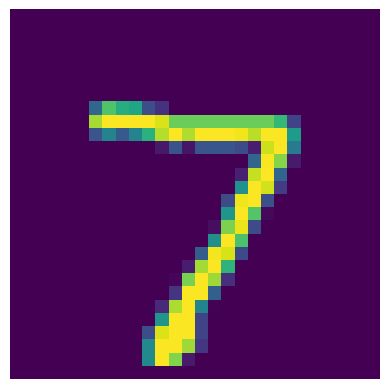

In [14]:
show_image(x, idx=0)

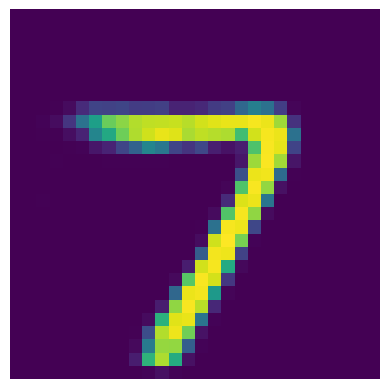

In [15]:
show_image(x_hat, idx=0)